# Preprocessing & Exploratory Data Analysis
## Bank Marketing Dataset — ML Lab Project (UPC-FIB, MDS 2026)

**Authors:** Arman Bazarchi, Ines Maria Madeira Prates

---

This notebook handles data loading, exploration, and preprocessing.  
The processed data is saved to `data/` so that all phase notebooks can reuse it without repeating this work.

### Outline
1. Data Loading & Initial Inspection
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Save Processed Data

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

---
## 1. Data Loading & Initial Inspection

In [96]:
import requests, zipfile, io

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"
response = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(response.content))

with z.open("bank-additional/bank-additional-full.csv") as f:
    df = pd.read_csv(f, sep=';')

print(f"Dataset shape: {df.shape}")
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1] - 1} + 1 target")
df.head()

Dataset shape: (41188, 21)
Number of samples: 41188
Number of features: 20 + 1 target


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [116]:
df.info()

dfs = (df['pdays'] != 999 ) & (df['poutcome'] == "failure")
df[dfs].head(10)




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
27832,30,student,single,high.school,no,no,no,cellular,mar,fri,...,5,10,2,failure,-1.8,92.843,-50.0,1.640,5099.1,yes
28218,28,student,single,university.degree,no,yes,no,cellular,apr,tue,...,3,11,2,failure,-1.8,93.075,-47.1,1.453,5099.1,no
28433,48,blue-collar,married,basic.4y,unknown,yes,no,cellular,apr,thu,...,2,5,3,failure,-1.8,93.075,-47.1,1.435,5099.1,no
30138,60,retired,divorced,professional.course,no,yes,no,cellular,apr,thu,...,1,5,2,failure,-1.8,93.075,-47.1,1.365,5099.1,yes
30544,42,admin.,married,professional.course,no,yes,no,cellular,may,mon,...,3,9,2,failure,-1.8,92.893,-46.2,1.354,5099.1,yes
31953,32,admin.,single,professional.course,no,yes,no,cellular,may,thu,...,2,7,2,failure,-1.8,92.893,-46.2,1.327,5099.1,no
33038,25,technician,single,university.degree,no,no,yes,cellular,may,mon,...,3,12,2,failure,-1.8,92.893,-46.2,1.299,5099.1,no
34498,33,admin.,single,high.school,no,no,no,cellular,may,thu,...,1,12,2,failure,-1.8,92.893,-46.2,1.266,5099.1,yes
34742,47,blue-collar,divorced,basic.9y,no,no,no,cellular,may,thu,...,8,6,2,failure,-1.8,92.893,-46.2,1.266,5099.1,no
35346,49,blue-collar,married,basic.9y,no,no,no,cellular,may,fri,...,2,9,2,failure,-1.8,92.893,-46.2,1.250,5099.1,no


In [98]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [117]:
# Identify feature types
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('y')

print(f"Numerical features ({len(numerical_cols)}): {numerical_cols}")
print(f"\nCategorical features ({len(categorical_cols)}): {categorical_cols}")
print(f"\nTarget: y")

# The dataset has a balanced mix of 10 numerical and 10 categorical features, 
# Numerical features include both client-level attributes (e.g., age) 
#   and macroeconomic indicators (e.g., euribor3m, nr.employed).

# Categorical features capture demographics (job, marital, education), financial status (default, housing, loan), 
#   and campaign details (contact, month, day_of_week, poutcome).



Numerical features (10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical features (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Target: y


---
## 2. Exploratory Data Analysis (EDA)

### 2.1 Target Variable Distribution

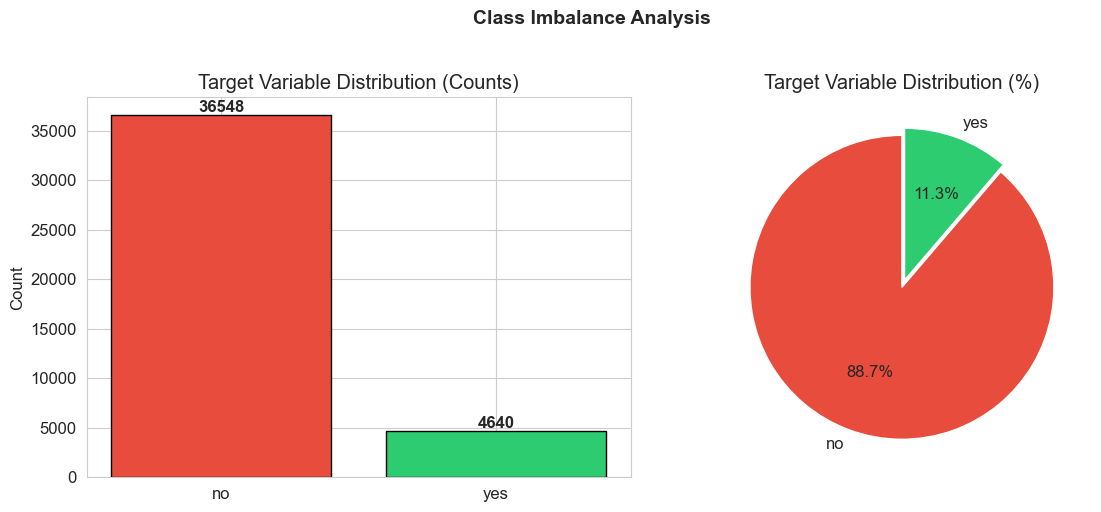

Imbalance ratio (no/yes): 7.88


In [100]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

class_counts = df['y'].value_counts()
axes[0].bar(class_counts.index, class_counts.values, color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Target Variable Distribution (Counts)')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 300, str(v), ha='center', fontweight='bold')

class_pct = df['y'].value_counts(normalize=True) * 100
axes[1].pie(class_pct.values, labels=class_pct.index, autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'], startangle=90, explode=(0, 0.05))
axes[1].set_title('Target Variable Distribution (%)')

plt.suptitle('Class Imbalance Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

ratio = class_counts['no'] / class_counts['yes']
print(f"Imbalance ratio (no/yes): {ratio:.2f}")


# The target is heavily imbalanced, this has two important implications:
# Accuracy is misleading — a naive model predicting "No" for every client would achieve ~89% 
#   accuracy while being useless. We must use metrics robust to imbalance: F1-score, ROC-AUC, and AUPR.

# Model training bias — most classifiers will be biased toward the majority class 
#   unless we address the imbalance (e.g., through class weights, or resampling techniques in later phases).



### 2.2 Numerical Features — Distributions by Target

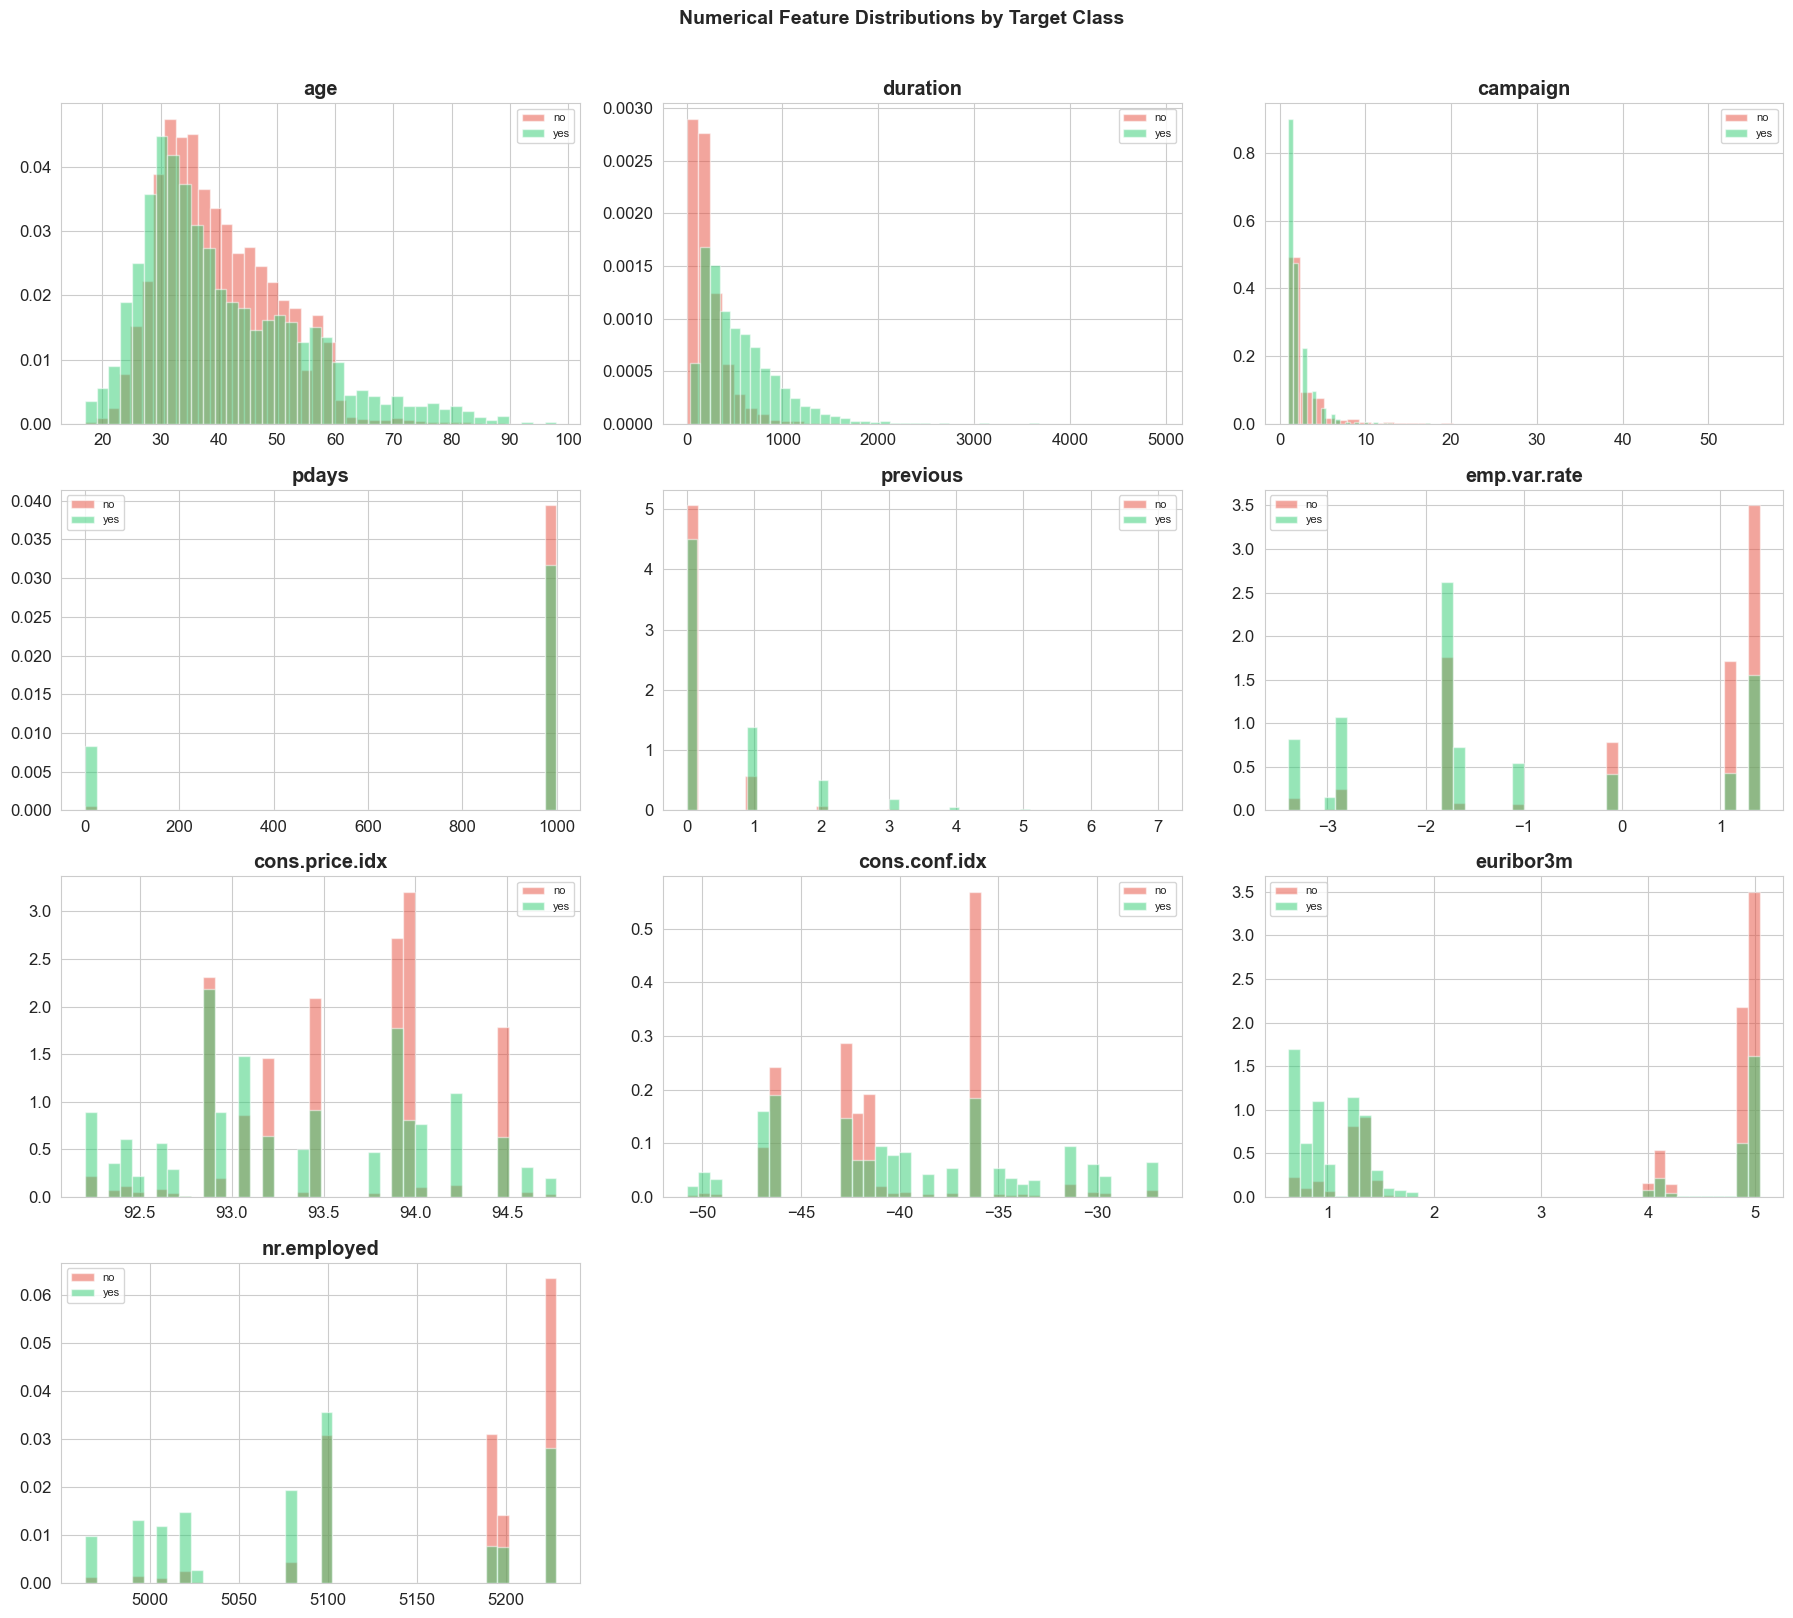

In [101]:
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    for label, color in [('no', '#e74c3c'), ('yes', '#2ecc71')]:
        subset = df[df['y'] == label][col]
        ax.hist(subset, bins=40, alpha=0.5, label=label, color=color, density=True)
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)

if len(numerical_cols) < len(axes):
    for j in range(len(numerical_cols), len(axes)):
        axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions by Target Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


    

### 2.3 Categorical Features — Subscription Rate per Category

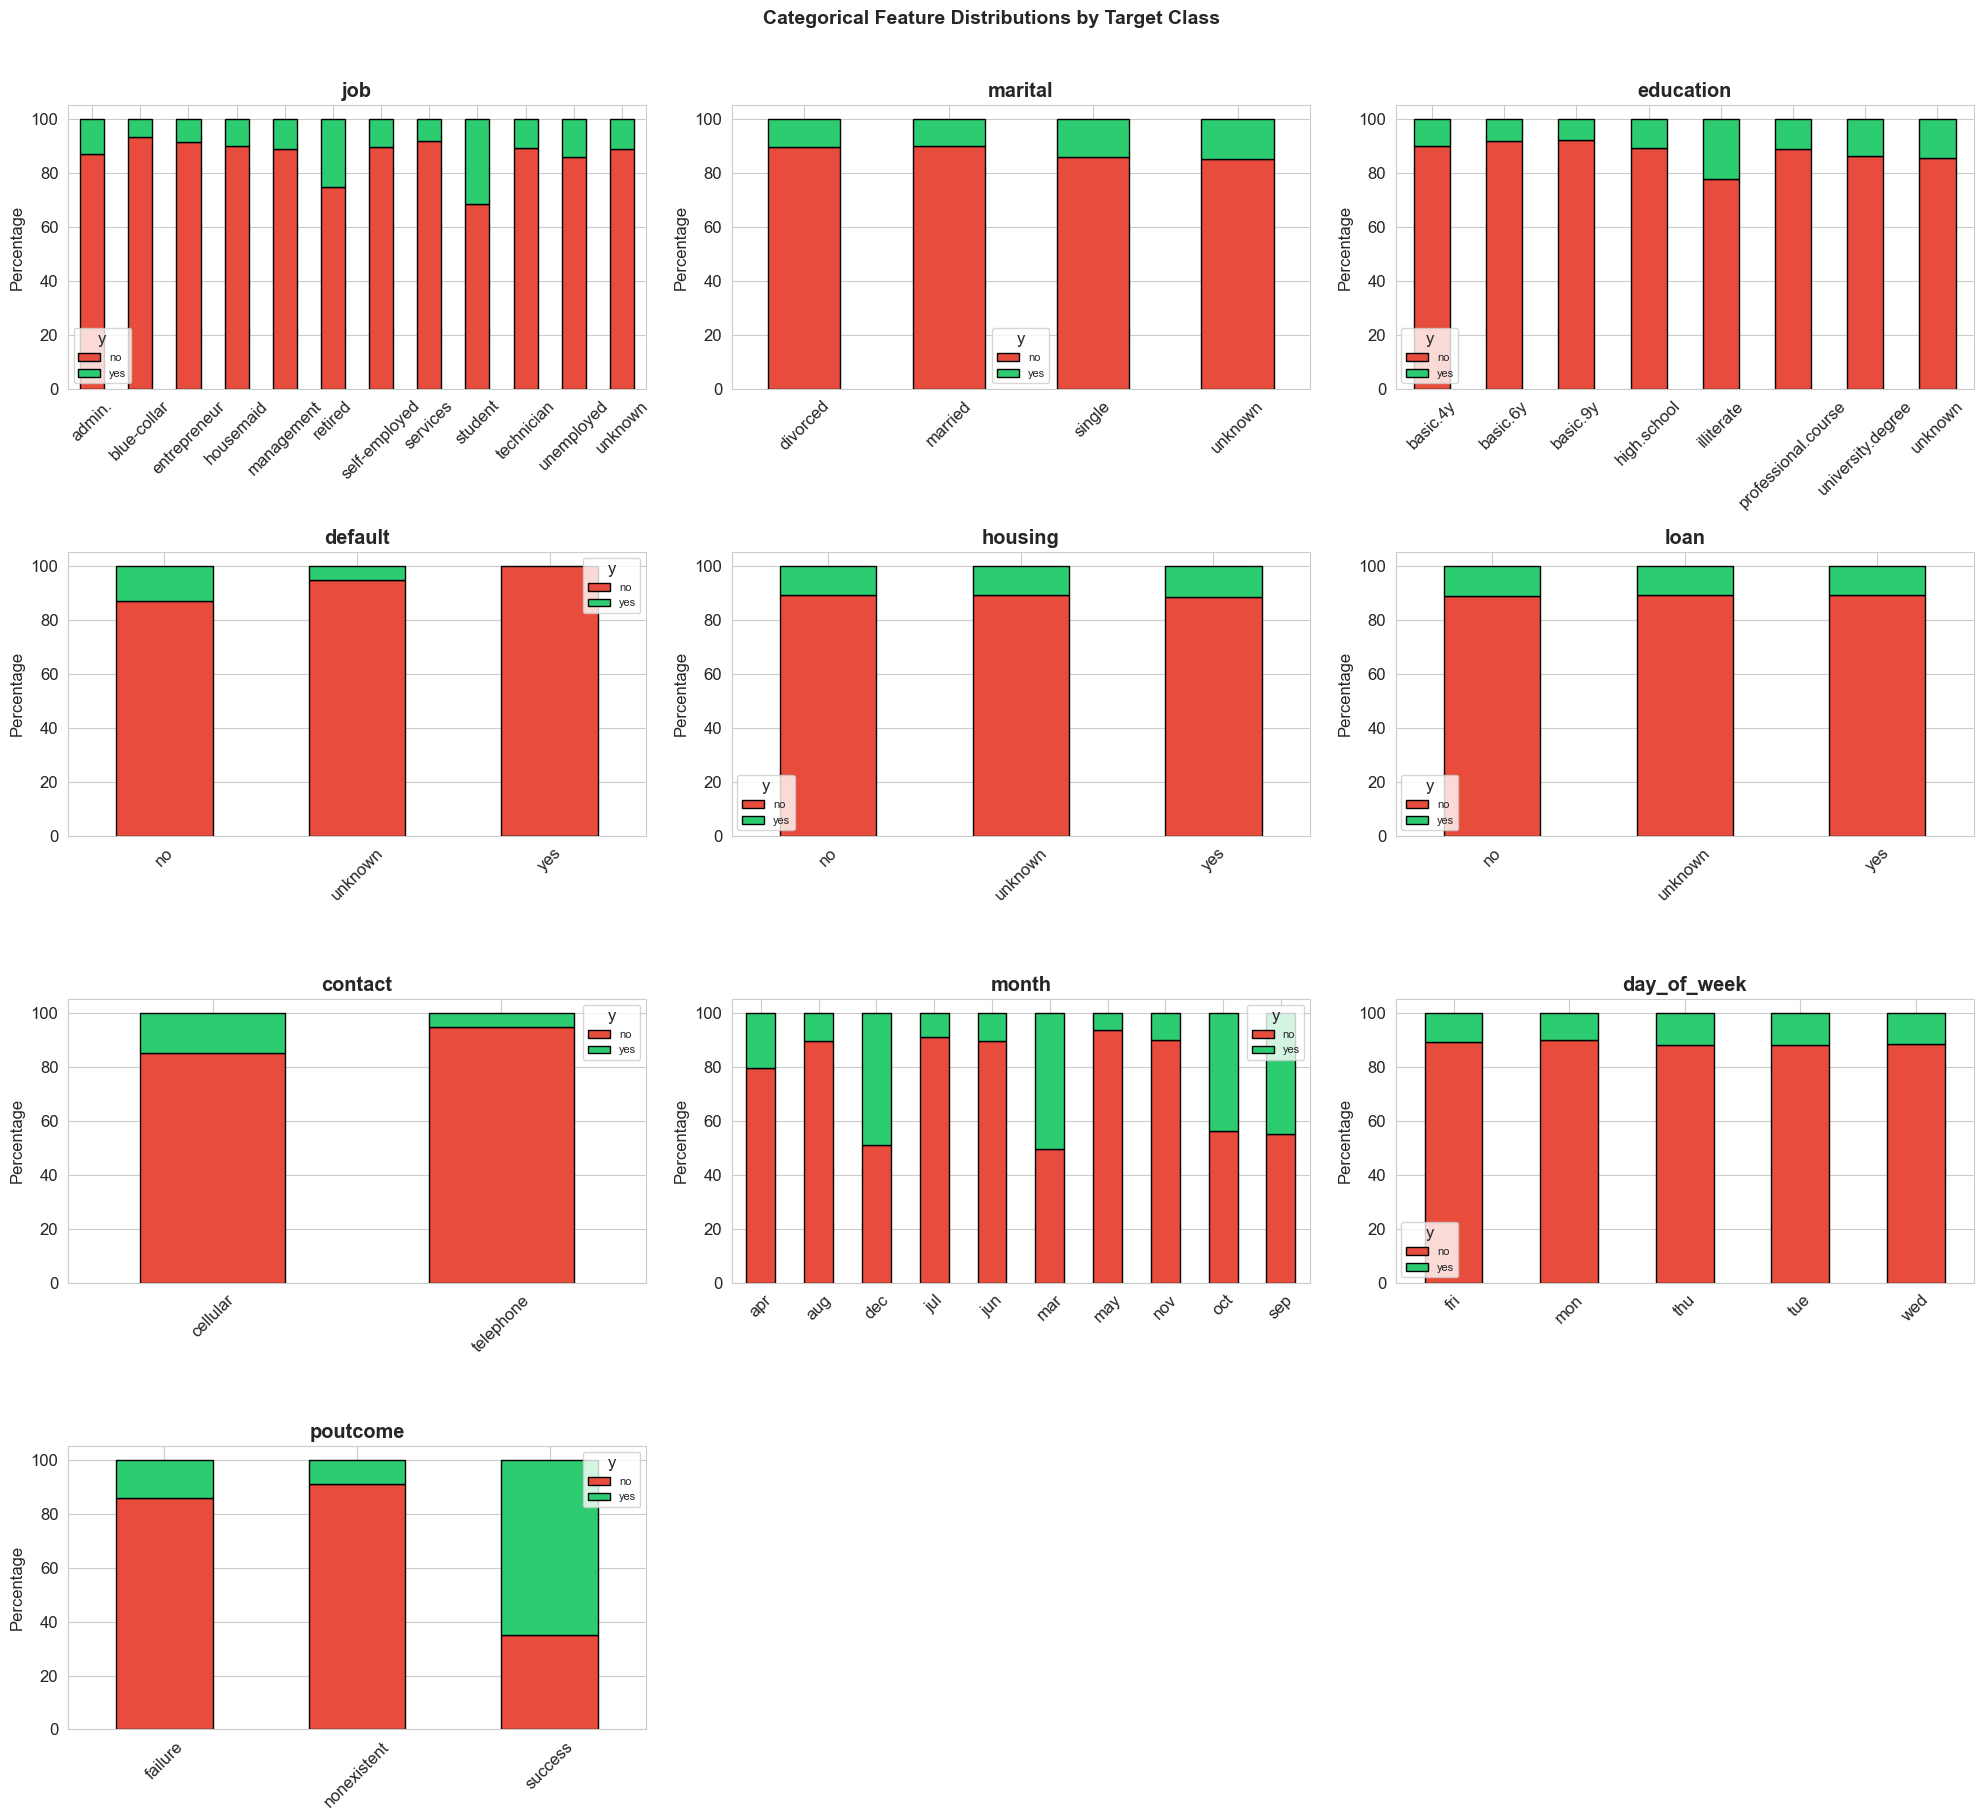

In [102]:
fig, axes = plt.subplots(4, 3, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    ct = pd.crosstab(df[col], df['y'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=ax, color=['#e74c3c', '#2ecc71'], edgecolor='black')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Percentage')
    ax.set_xlabel('')
    ax.legend(title='y', fontsize=8)
    ax.tick_params(axis='x', rotation=45)

for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Distributions by Target Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


# poutcome can be strongest categorical predictor, clients with a successful previous campaign outcome 
#   subscribe at a much higher rate (65%) compared to those who failed (14%) or were never contacted (~9%).

# contact: Cellular contact shows a higher subscription rate than telephone, possibly reflecting 
#   clients reachable on mobile may be more engaged.

# month: March, December, September, and October show higher subscription rates, these may correspond to 
#   specific campaign strategies or economic conditions during those periods rather than a seasonal effect.

# job: Retired and student groups show higher subscription rates, possibly due to different 
#   financial needs or availability for longer calls.

# education: Illiterate clients show a notably higher rate, but with very few samples — likely not reliable. 
# University degree holders subscribe slightly more than average.

# default: Almost no clients with default=yes exist in the data (only 3 records with target=no), 
#   making this feature potentially uninformative. The high proportion of unknown (20.9%) is notable.




### 2.4 Correlation Matrix (Numerical Features)

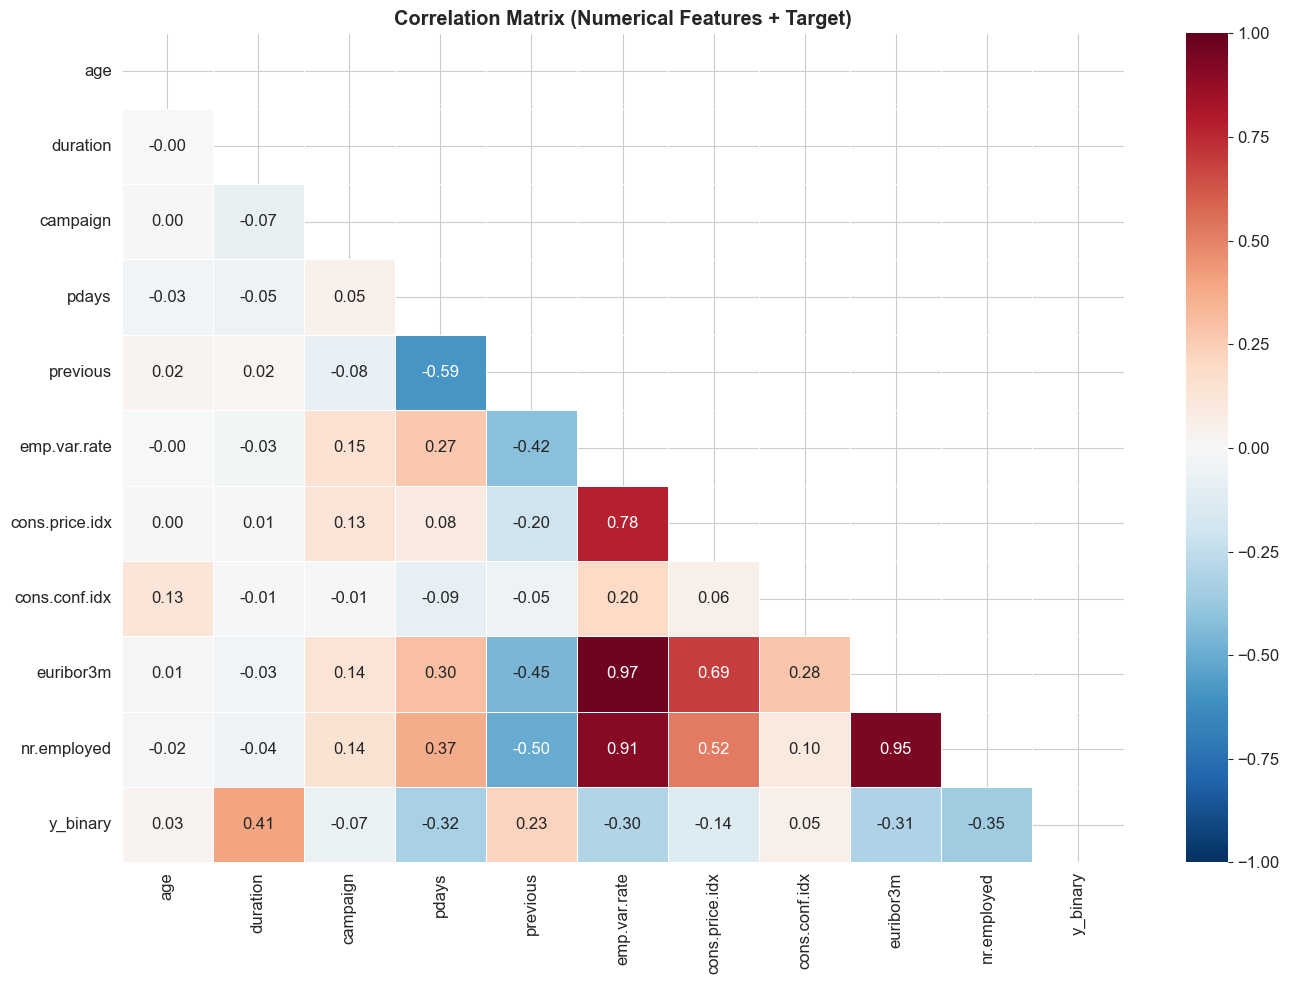

In [103]:
df_corr = df[numerical_cols].copy()
df_corr['y_binary'] = (df['y'] == 'yes').astype(int)

corr_matrix = df_corr.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix (Numerical Features + Target)', fontweight='bold')
plt.tight_layout()
plt.show()

# Strong inter-feature correlations: euribor3m, emp.var.rate, and nr.employed are highly 
#   correlated with each other (|r| > 0.9), this is expected as they are all macroeconomic indicators 
#   reflecting the same economic conditions, this multicollinearity can affect 
#   linear models (coefficient instability) and suggests that PCA could help compress these into fewer dimensions.

# Target correlations: duration has the highest correlation with the target (r = 0.41), but it is leaky. 
# Among usable features, nr.employed (r = -0.35), euribor3m (r = -0.31), and emp.var.rate (r = -0.30) are 
#   the most correlated, all negative, confirming that favorable economic 
#   conditions (lower rates, lower employment) coincide with higher subscription rates.

# Weak individual predictors: age (r = 0.03) and cons.conf.idx (r = 0.05) show almost no linear 
#   relationship with the target, though they may still contribute through non-linear interactions 
#   captured by kernel methods in later phases.


In [104]:
target_corr = corr_matrix['y_binary'].drop('y_binary').sort_values(key=abs, ascending=False)
print("Correlation with target (y_binary):\n")
print(target_corr.to_string())

Correlation with target (y_binary):

duration          0.405274
nr.employed      -0.354678
pdays            -0.324914
euribor3m        -0.307771
emp.var.rate     -0.298334
previous          0.230181
cons.price.idx   -0.136211
campaign         -0.066357
cons.conf.idx     0.054878
age               0.030399


### 2.5 Pairplot — Top Features by Target

We select the features with the highest absolute correlation to the target and visualize pairwise relationships.

Top 5 features by |correlation| with target: ['duration', 'nr.employed', 'pdays', 'euribor3m', 'emp.var.rate']


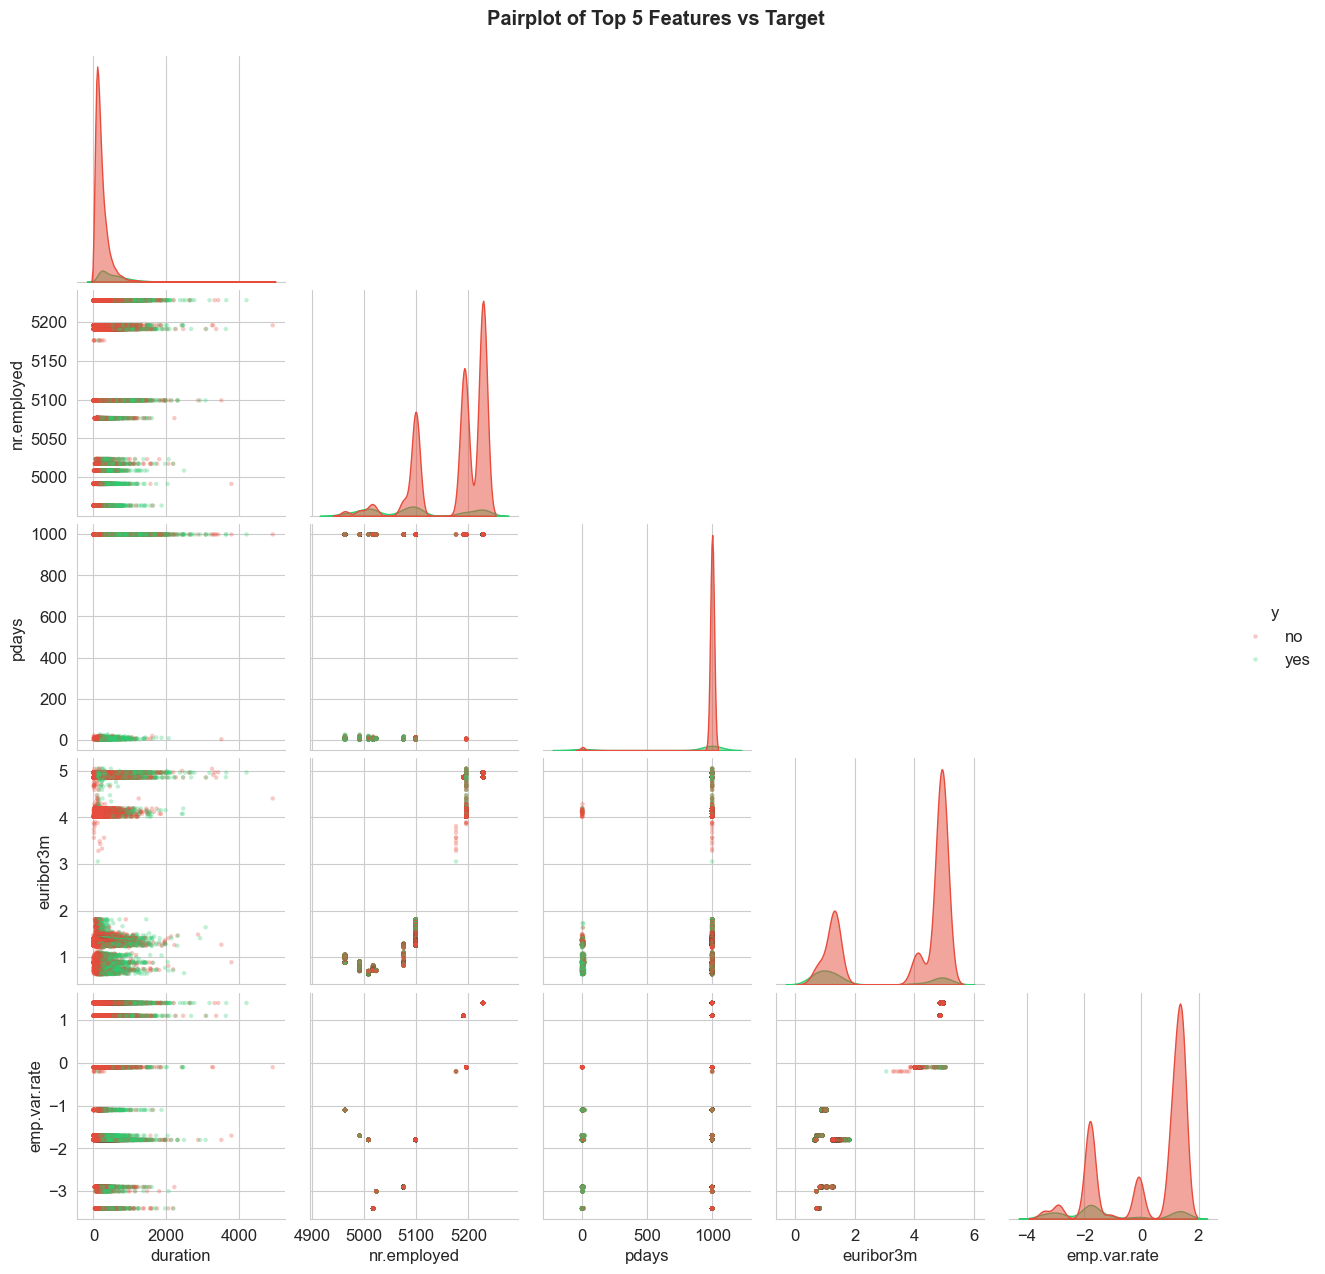

In [105]:
top_n = 5
top_features = target_corr.abs().head(top_n).index.tolist()

print(f"Top {top_n} features by |correlation| with target: {top_features}")

pairplot_df = df[top_features + ['y']].copy()

g = sns.pairplot(pairplot_df, hue='y', corner=True,
                 palette={'no': '#e74c3c', 'yes': '#2ecc71'},
                 plot_kws={'alpha': 0.3, 's': 10, 'edgecolor': 'none'},
                 diag_kws={'alpha': 0.5})
g.figure.suptitle(f'Pairplot of Top {top_n} Features vs Target', y=1.02, fontweight='bold')
plt.show()


# duration vs other features: Subscribers (green) tend to cluster at higher duration values across all pairings, 
#   reinforcing its strong but leaky predictive effect.

# nr.employed vs euribor3m: These two features show a tight near-linear relationship, 
#   confirming the multicollinearity we observed in the correlation matrix. 
#   Subscribers are concentrated in the lower-left region (low employment, low interest rates).

# pdays: The 999 sentinel dominates the scatter, creating a horizontal/vertical band that obscures relationships. 
#   this further motivates keeping pdays as-is (since the sentinel naturally separates never-contacted clients) 
#   and relying on poutcome for the categorical distinction.

# No single feature pair cleanly separates the classes, confirming that the classification problem is 
#    non-trivial and will likely require non-linear models (SVM with RBF kernel, ensemble methods) 
#    for good performance.



### 2.6 Discussion: `duration` Feature

As we pointet in the dataset documentation and our proposal, `duration` (last contact duration in seconds) is **highly predictive but causes data leakage**: it is only known after the call ends, so it cannot be used for a realistic predictive model.

We keep it in the EDA to understand the data structure, but we **exclude it from all supervised models** in later phases.

### 2.7 Missing Values & 'Unknown' Entries

In [106]:
print("Standard NaN missing values per column:")
print(df.isnull().sum())
print(f"\nTotal NaN values: {df.isnull().sum().sum()}")

Standard NaN missing values per column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Total NaN values: 0


In [107]:
print("'unknown' counts per categorical feature:\n")
for col in categorical_cols:
    n_unknown = (df[col] == 'unknown').sum()
    pct_unknown = n_unknown / len(df) * 100
    if n_unknown > 0:
        print(f"  {col}: {n_unknown} ({pct_unknown:.2f}%)")

n_pdays_999 = (df['pdays'] == 999).sum()
print(f"\npdays = 999 (not previously contacted): {n_pdays_999} ({n_pdays_999/len(df)*100:.2f}%)")


# The dataset has no standard NaN values, but 'unknown' entries serve as missing or 
#   not given data in several categorical features:

# default (20.87%): The most affected, over 1 in 5 clients have unknown credit default status. 
#   This is a substantial proportion and could impact models that rely heavily on this feature.

# education (4.20%), housing and loan (2.40% each): Moderate levels of unknowns.
# job (0.80%), marital (0.19%): Minimal unknowns.

# We treat 'unknown' as a valid category rather than imputing or dropping these records:
#  The 'unknown' status may itself carry information — clients who refuse to disclose their 
#  credit default status may behave differently from those who openly report it.
# Dropping 20.87% of records (for default alone) would significantly reduce our dataset.
# We encode 'unknown' as a separate code (2) for binary categoricals, preserving the distinction.

# pdays = 999 affects 96.32% of records — this is not missing data but a sentinel indicating "never contacted 
#  in a previous campaign".



'unknown' counts per categorical feature:

  job: 330 (0.80%)
  marital: 80 (0.19%)
  education: 1731 (4.20%)
  default: 8597 (20.87%)
  housing: 990 (2.40%)
  loan: 990 (2.40%)

pdays = 999 (not previously contacted): 39673 (96.32%)


---
## 3. Data Preprocessing

We treat the target variable as binary.

In [108]:
df_processed = df.copy()

# Encode target variable
df_processed['y'] = (df_processed['y'] == 'yes').astype(int)
print(f"Target encoding: no -> 0, yes -> 1")
print(f"Target distribution: {df_processed['y'].value_counts().to_dict()}")

Target encoding: no -> 0, yes -> 1
Target distribution: {0: 36548, 1: 4640}


### 3.2 Encoding Categorical Features

- **Ordinal encoding** for `education` (natural order exists)
- **Ordinal encoding** for `poutcome` — not contacted (0) → failure (1) → success (2)
- **Binary encoding** for `contact` (only 2 values: cellular / telephone)
- **Integer encoding** for `default`, `housing`, `loan` — 'unknown' gets its own code

In [109]:
# Ordinal: education
education_order = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
                   'high.school', 'professional.course', 'university.degree', 'unknown']
df_processed['education'] = df_processed['education'].map(
    {val: i for i, val in enumerate(education_order)}
)

# Ordinal: poutcome (not contacted < failure < success)
df_processed['poutcome'] = df_processed['poutcome'].map(
    {'nonexistent': 0, 'failure': 1, 'success': 2}
)

# Binary: contact (cellular=1, telephone=0)
df_processed['contact'] = (df_processed['contact'] == 'cellular').astype(int)

# Integer: binary categoricals with 'unknown'
binary_cats = ['default', 'housing', 'loan']
for col in binary_cats:
    df_processed[col] = df_processed[col].map({'no': 0, 'yes': 1, 'unknown': 2})


print(f"Shape after encoding: {df_processed.shape}")
print(f"\nColumns: {list(df_processed.columns)}")


# education → ordinal (0–7): Education levels have a natural order from illiterate to university.degree. 
#   Ordinal encoding preserves this hierarchy, a model can learn that higher education levels have a monotonic 
#   relationship with the target, we place unknown at the end (7) as a separate level.

# poutcome → ordinal (0–2): There is a clear progression: no prior campaign (0) → prior campaign that failed (1) → 
#   prior campaign that succeeded (2), this ordering captures the fact that a previous success is a stronger positive 
#   signal than a failure, which in turn is more informative than no prior contact. 
#   One-hot encoding would discard this ordinal relationship.

# contact → binary (0/1): With only two values (telephone, cellular), one-hot encoding would produce two perfectly 
#   inversely correlated columns — redundant, a single binary column is cleaner.

# default, housing, loan → integer (0/1/2): These are binary features (no/yes) with an unknown category. 
#   We use 0/1/2 to preserve all three states, as an alternative, one-hot encoding (3 columns each), 
#   but integer encoding is more compact and unknown as a third code lets models treat it distinctly.


Shape after encoding: (41188, 21)

Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


### 3.3 Handling `pdays` Sentinel Value

`previous=0`, `poutcome="nonexistent"` (encoded as 0), and `pdays=999` should all co-occur for clients never contacted in a previous campaign. However, `pdays=999` also appears in records where `previous>0` and `poutcome` indicates a real outcome (failure/success), suggesting the 999 is used as "not available" rather than strictly "never contacted."

We first verify the one-directional consistency, then separate truly never-contacted clients (`pdays = -1`) from those with missing pdays data (remaining 999s).

In [110]:
# Step 1: verify one-directional consistency
# (previous=0 should always have poutcome=0 and pdays=999)
# note: poutcome is already encoded as 0=nonexistent, 1=failure, 2=success
viol1 = (df_processed['previous'] == 0) & (df_processed['poutcome'] != 0)
viol2 = (df_processed['previous'] == 0) & (df_processed['pdays'] != 999)
viol3 = (df_processed['poutcome'] == 0) & (df_processed['pdays'] != 999)

# check for NaN in poutcome (can happen if cell-27 is re-run on already-encoded data)
if df_processed['poutcome'].isna().any():
    print("WARNING: poutcome contains NaN values — restart kernel and re-run from the top")
else:
    n1, n2, n3 = viol1.sum(), viol2.sum(), viol3.sum()

    if n1 == 0 and n2 == 0 and n3 == 0:
        print("One-directional consistency checks PASSED")
        print(f"  previous=0 always has poutcome=0 and pdays=999")
    else:
        print("Consistency checks FAILED")
        if n1 > 0: print(f"  {n1} records with previous=0 but poutcome!=0")
        if n2 > 0: print(f"  {n2} records with previous=0 but pdays!=999")
        if n3 > 0: print(f"  {n3} records with poutcome=0 but pdays!=999")

    # Check reverse: how many records have pdays=999 but WERE contacted before?
    reverse = (df_processed['pdays'] == 999) & (df_processed['previous'] > 0)
    print(f"\n  Reverse check: pdays=999 but previous>0: {reverse.sum()} records")
    print(f"  These are clients who were contacted but pdays was not tracked")

One-directional consistency checks PASSED
  previous=0 always has poutcome=0 and pdays=999

  Reverse check: pdays=999 but previous>0: 4110 records
  These are clients who were contacted but pdays was not tracked


In [112]:
# Step 2: separate truly never-contacted from unknown-days records
# (previous=0 AND poutcome=0 confirms no prior campaign contact)
never_contacted = (df_processed['previous'] == 0) & (df_processed['poutcome'] == 0)
contacted_unknown = (df_processed['pdays'] == 999) & ~never_contacted
contacted_real = (df_processed['pdays'] != 999) & ~never_contacted

print(f"pdays breakdown:")
print(f"  Never contacted (previous=0, poutcome=0, pdays=999): {never_contacted.sum()}")
print(f"  Contacted, days unknown (pdays=999, previous>0):     {contacted_unknown.sum()}")
print(f"  Contacted, days known (real pdays):                  {contacted_real.sum()}")
print(f"  Total: {never_contacted.sum() + contacted_unknown.sum() + contacted_real.sum()}")
print(f"\n  → Only {contacted_real.sum()/len(df_processed)*100:.1f}% of records have real pdays values where gives us more information than poutcome, and prevoius")

pdays breakdown:
  Never contacted (previous=0, poutcome=0, pdays=999): 35563
  Contacted, days unknown (pdays=999, previous>0):     4110
  Contacted, days known (real pdays):                  1515
  Total: 41188

  → Only 3.7% of records have real pdays values where gives us more information than poutcome, and prevoius


In [113]:
# Step 3: investigate the unknown-days records to decide: impute or drop?
remaining_999 = df_processed[contacted_unknown]
real_pdays_df = df_processed[contacted_real]

print(f"Unknown-days records ({len(remaining_999)}):")
print(f"\n  Breakdown by poutcome (1=failure, 2=success):")
print(remaining_999['poutcome'].value_counts().sort_index().to_string())
print(f"\n  Breakdown by previous (number of prior contacts):")
print(remaining_999['previous'].value_counts().sort_index().to_string())

print(f"\n  Duration comparison across pdays groups:")
print(f"  {'Group':<35s} {'Count':>6s} {'Mean':>8s} {'Median':>8s} {'Std':>8s}")
print(f"  {'-'*65}")
for label, mask in [('Never contacted (pdays=999)',      never_contacted),
                     ('Contacted, days unknown (pdays=999)', contacted_unknown),
                     ('Contacted, days known (real pdays)',   contacted_real)]:
    d = df_processed.loc[mask, 'duration']
    print(f"  {label:<35s} {len(d):>6d} {d.mean():>8.1f} {d.median():>8.1f} {d.std():>8.1f}")

print(f"\n  Real pdays range: {real_pdays_df['pdays'].min()} – {real_pdays_df['pdays'].max()}, "
      f"mean: {real_pdays_df['pdays'].mean():.1f}")
print(f"\n  → All {len(remaining_999)} unknown records have poutcome=failure")
print(f"  → Imputing {len(remaining_999)} from only {len(real_pdays_df)} donors is unreliable")
print(f"  → Decision: drop pdays")

Unknown-days records (4110):

  Breakdown by poutcome (1=failure, 2=success):
poutcome
1    4110

  Breakdown by previous (number of prior contacts):
previous
1    3696
2     349
3      50
4      12
5       2
6       1

  Duration comparison across pdays groups:
  Group                                Count     Mean   Median      Std
  -----------------------------------------------------------------
  Never contacted (pdays=999)          35563    257.1    177.0    262.3
  Contacted, days unknown (pdays=999)   4110    245.4    178.0    230.3
  Contacted, days known (real pdays)    1515    321.5    253.0    254.7

  Real pdays range: 0 – 27, mean: 6.0

  → All 4110 unknown records have poutcome=failure
  → Imputing 4110 from only 1515 donors is unreliable
  → Decision: drop pdays (see Step 4)


In [118]:
# Step 4: drop pdays
# After investigation, we drop pdays entirely rather than imputing. Rationale:
#
# 1. Data quality: 86.3% are never-contacted (sentinel), 10% have unknown days,
#    only 3.7% have real values. Imputing 4,110 records from 1,515 donors means
#    more invented data than actual data — any model signal from pdays would be
#    largely artificial.
#
# 2. Redundancy: poutcome already encodes whether and how the previous campaign
#    ended (not contacted / failure / success), and previous captures how many
#    times the client was contacted. The only unique information pdays would add
#    is recency of last contact — but we don't know that for 96.3% of clients.
#
# 3. Methodological soundness: a well-justified variable drop is stronger than
#    a technically sophisticated imputation on unreliable data. We preserve the
#    campaign history signal through poutcome and previous.

df_processed = df_processed.drop(columns=['pdays'])
print(f"Dropped 'pdays' — shape after drop: {df_processed.shape}")
print(f"Remaining campaign-history features: poutcome, previous")
print(f"  poutcome values: {sorted(df_processed['poutcome'].unique())}")
print(f"  previous range:  {df_processed['previous'].min()} – {df_processed['previous'].max()}")

Dropped 'pdays' — shape after drop: (41188, 20)
Remaining campaign-history features: poutcome, previous
  poutcome values: [np.int64(0), np.int64(1), np.int64(2)]
  previous range:  0 – 7


### 3.4 Feature Scaling

We standardize all features (zero mean, unit variance). This is important for PCA and distance-based methods (K-Means).

We save both the unscaled processed dataframe (for interpretability) and the scaled feature matrix.

In [119]:
from sklearn.preprocessing import StandardScaler

# Separate categorical string columns (to be encoded per-phase) from numeric columns (to be scaled)
cat_string_cols = ['job', 'marital', 'month', 'day_of_week']
numeric_cols = [c for c in df_processed.columns if c not in cat_string_cols + ['y']]

X_numeric = df_processed[numeric_cols]
y = df_processed['y']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_cols)

print(f"Scaled numeric features: {len(numeric_cols)}")
print(f"Categorical string features (saved separately): {cat_string_cols}")
print(f"\nScaled feature matrix shape: {X_scaled_df.shape}")
print(f"Mean (first 5): {X_scaled[:, :5].mean(axis=0).round(6)}")
print(f"Std  (first 5): {X_scaled[:, :5].std(axis=0).round(6)}")

# We scale only the numeric/encoded features. The 4 categorical string columns (job, marital, month, day_of_week)
# are kept unscaled — each phase notebook will encode them as needed:
#   - One-hot encoding for PCA, Logistic Regression, SVM (Phase I–III)
#   - Native categorical handling for tree-based models (Phase IV)

Scaled numeric features: 15
Categorical string features (saved separately): ['job', 'marital', 'month', 'day_of_week']

Scaled feature matrix shape: (41188, 15)
Mean (first 5): [-0.  0.  0. -0.  0.]
Std  (first 5): [1. 1. 1. 1. 1.]


**Decision rationale — StandardScaler:**

We chose standardization (zero mean, unit variance) over alternatives because:
- **PCA** (Phase I) requires features on the same scale — otherwise components would be dominated by high-variance features like `pdays` (range 0–999) or `nr.employed` (range ~4964–5228), while binary one-hot features (range 0–1) would contribute almost nothing.
- **K-Means** (Phase I) uses Euclidean distance, which is sensitive to feature scales.
- **SVM** (Phase III) and **Logistic Regression** (Phase II) also benefit from standardized inputs for faster convergence and fair regularization.

Note: Tree-based models (Phase IV) are scale-invariant, but we apply the same preprocessing for consistency across all phases. The unscaled `df_processed.csv` is also saved for interpretability and profiling.

---
## 4. Save Processed Data

In [ ]:
df_processed.to_csv('data/df_processed.csv', index=False)
X_scaled_df.to_csv('data/X_scaled.csv', index=False)
y.to_csv('data/y.csv', index=False)
pd.DataFrame({'feature': numeric_cols}).to_csv('data/feature_names.csv', index=False)

# Save categorical string columns alongside scaled features so phase notebooks can reconstruct the full dataset
df_processed[cat_string_cols].to_csv('data/cat_features.csv', index=False)

# Also save the original raw dataframe for reference in later analyses
df.to_csv('data/df_raw.csv', index=False)

print("Saved to data/:")
print(f"  df_raw.csv        — original data ({df.shape})")
print(f"  df_processed.csv  — encoded, unscaled ({df_processed.shape})")
print(f"  X_scaled.csv      — standardized numeric features ({X_scaled_df.shape})")
print(f"  cat_features.csv  — categorical string columns ({len(cat_string_cols)} cols)")
print(f"  y.csv             — target ({y.shape})")
print(f"  feature_names.csv — {len(numeric_cols)} scaled feature names")

---
### Summary

**Dataset:** 41,188 samples, 20 features (10 numerical, 10 categorical), 1 binary target.  
**Imbalance:** 88.7% No / 11.3% Yes (ratio ~7.9:1).  
**Missing values:** No NaNs; several categoricals have 'unknown' entries (treated as valid category).  
**`duration`:** Highly predictive but leaky -- will be excluded from supervised models.  
**`pdays`:** Dropped after investigation -- 96.3% of values are sentinel (999) with no real information; only 3.7% have actual day counts. The campaign-history signal is preserved through `poutcome` (outcome) and `previous` (contact count).  
**Encoding:** Ordinal for `education` and `poutcome`, binary for `contact`, integer for `default`/`housing`/`loan`; `job`/`marital`/`month`/`day_of_week` kept as categorical strings for phase-specific encoding.  
**Scaling:** StandardScaler applied to 15 numeric/encoded features. The 4 categorical string columns are saved separately in `cat_features.csv`.

*Processed data is ready in `data/` for use by all phase notebooks.*